In [334]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from linearmodels.panel import PanelOLS
from scipy import stats as scipy_stats
import statsmodels.formula.api as smf
from linearmodels.panel.results import compare
import statsmodels.api as sm

from tqdm.notebook import tqdm
from itables import init_notebook_mode

In [299]:
book_colors = {
    'primary': '#2E86AB',    # Steel blue - main data
    'secondary': '#A23B72',  # Magenta - secondary data
    'accent': '#F18F01',     # Orangxe - highlights/warnings
    'success': '#C73E1D',    # Red-orange - thresholds/targets
    'muted': '#6C757D',      # Gray - reference lines
    'light_gray': '#E5E5E5', # Light gray - backgrounds
    'dark_gray': '#4D4D4D'   # Dark gray - text
}

def setup_book_style():
    """Apply consistent styling to matplotlib plots"""
    plt.rcParams.update({
        'figure.figsize': (10, 7),
        'figure.dpi': 100,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.labelsize': 14,
        'axes.labelcolor': '#4D4D4D',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.color': '#E5E5E5',
        'legend.fontsize': 11,
        'legend.frameon': False,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    })

setup_book_style()

In [191]:
def plot_event_margins(model, measure_unit = 'RUB'):
    coef_names = [col for col in model.params.index if col.startswith('rel_period')]
    coefs = model.params[coef_names]
    std_errors = model.std_errors[coef_names]
    
    # Parse relative periods from coefficient names
    rel_periods = [int(name.split('_')[2]) for name in coef_names]
    
    # Create DataFrame for plotting
    coef_df = pd.DataFrame({
        'relative_period': rel_periods,
        'estimate': coefs.values,
        'std_error': std_errors.values
    })
    
    # Add reference period (k = -1) with zero effect
    ref_row = pd.DataFrame({
        'relative_period': [-1],
        'estimate': [0],
        'std_error': [0]
    })
    coef_df = pd.concat([coef_df, ref_row], ignore_index=True)
    coef_df = coef_df.sort_values('relative_period').reset_index(drop=True)
    
    # Calculate confidence intervals (95%)
    coef_df['ci_lower'] = coef_df['estimate'] - 1.96 * coef_df['std_error']
    coef_df['ci_upper'] = coef_df['estimate'] + 1.96 * coef_df['std_error']
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Shade pre-treatment region
    ax.axvspan(-6.5, -0.5, alpha=0.15, color=book_colors['light_gray'], zorder=0)
    
    # Reference lines
    ax.axhline(y=0, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)
    ax.axvline(x=-0.5, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)

    ax.axvline(x=-1, linestyle='--', color='red', linewidth=1, alpha=0.8)
    ax.axvline(x=1, linestyle='--', color='red', linewidth=1, alpha=0.8)

    # ax.annotate('pandemic restrictions\nperiod of interest',
    #             xy=(0, coef_df['ci_upper'].min() * 0.5),
    #             fontsize=10, color='red', ha='center', style='italic')
    
    # Error bars
    ax.errorbar(
        coef_df['relative_period'],
        coef_df['estimate'],
        yerr=[coef_df['estimate'] - coef_df['ci_lower'],
              coef_df['ci_upper'] - coef_df['estimate']],
        fmt='o',
        color=book_colors['primary'],
        markersize=8,
        capsize=4,
        capthick=1.5,
        linewidth=1.5,
        ecolor=book_colors['primary'],
        zorder=3
    )
    
    # Annotations
    ax.annotate('Pre-pandemic',
                xy=(-3.5, coef_df['ci_upper'].max() * 0.6),
                fontsize=10, color=book_colors['muted'], ha='center', style='italic')
    
    ax.annotate('Post-pandemic',
                xy=(2.5, coef_df['ci_upper'].max() * 0.95),
                fontsize=10, color=book_colors['primary'], ha='center', style='italic')
    
    # Labels and title
    ax.set_xlabel('Periods', fontsize=14, color=book_colors['dark_gray'])
    ax.set_ylabel(f'Estimated effect ({measure_unit})', fontsize=14, color=book_colors['dark_gray'])
    ax.set_title('Effect of covid-19 restrictions on NEI',
                 fontsize=16, fontweight='bold', color='#333333', pad=15)
    
    # Subtitle
    ax.text(0.5, 1.02, 'Reference period: k = -1 (one period before treatment)',
            transform=ax.transAxes, fontsize=11, color='grey', ha='center')
    
    # Caption (takeaway)
    fig.text(0.1, -0.02,
             'Takeaway: No significant pre-trends; effect peaks at k=1, then gradually declines.',
             fontsize=9, color='grey', ha='left')
    
    ax.set_xticks(range(-6, 4))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.show()

In [332]:
def wald_test_for_period_insignificance(event_study_model_reduced):
    pre_treatment_terms = [t for t in event_study_terms if int(t.split('_')[2]) < -1]
    pre_coefs = event_study_model_reduced.params[pre_treatment_terms].values
    pre_vcov = event_study_model_reduced.cov.loc[pre_treatment_terms, pre_treatment_terms].values

    q = len(pre_treatment_terms)
    wald_stat = pre_coefs @ np.linalg.inv(pre_vcov) @ pre_coefs / q
    df_resid = event_study_model_reduced.nobs - event_study_model_reduced.params.shape[0]
    p_value = 1 - scipy_stats.f.cdf(wald_stat, q, df_resid)
    
    print(f"\nJoint F-test for pre-treatment coefficients:")
    print(f"  F({q}, {df_resid}) = {wald_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")

# goals:
* health disability variables
* unbiased penstion and job income
* all incomes

# data

In [15]:
panel = pl.read_parquet('../data/RLMS_IND_2015_2024_eng_prepared.parquet')
panel

id_w,idind,year,redid_i,id_i,id_h,origsm,inwgt,region,psu,status,popul,int_y,adult,child,marst,occup08,educ,diplom,diplom_1,site,h3,h4,h4_1,h4_1_y,h5,h6,h7_1,h7_2,h7_1_l,h7_2_l,h8a,h8b,h8a_l,h8b_l,born_m,age,…,l81_2,l81_3,l81_4,l81_5,l81_6,l81_7,l81_8,m20_68,o6,o7a,o7b,o8,o9a,o9b,o10,o11a,o11b,o12a,o12b,o13a,o13b,s1_1,s1_2,s2,s3,s4,s5,s6,s7,s1_1_l,s1_2_l,s2_l,s3_l,s4_l,s5_l,s6_l,s7_l
str,f64,f64,f64,f64,f64,str,f64,str,str,str,f64,f64,str,str,str,str,str,str,str,f64,f64,f64,str,f64,str,f64,f64,str,f64,null,f64,f64,f64,f64,str,f64,…,str,str,str,str,str,str,str,null,null,f64,f64,null,f64,f64,null,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,null,null,null,null,null,null,null,null
"""2014""",34896.0,2014.0,629901.0,5.8017601e7,580176.0,"""Yes, it is an adress from the …",1.022644,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""","""Managers""","""Institute, University, Academy…","""Higher education Diploma and m…","""Higher education Diploma and m…",58.0,176.0,1.0,"""Yes""",2013.0,"""MALE""",1948.0,5.0,"""January""",null,null,0.0,55.0,null,null,null,66.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""No""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",null,null,null,null,null,null,null,null
"""2014""",34897.0,2014.0,629902.0,5.8017602e7,580176.0,"""Yes, it is an adress from the …",0.923919,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""",null,"""Secondary School Diploma""","""Secondary School Diploma""","""Secondary School Diploma""",58.0,176.0,2.0,"""Yes""",2013.0,"""FEMALE""",1952.0,5.0,"""January""",null,null,0.0,40.0,null,null,null,62.5,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""No""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",null,null,null,null,null,null,null,null
"""2014""",34907.0,2014.0,630001.0,5.8018001e7,580180.0,"""Yes, it is an adress from the …",0.911524,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""",null,"""10 and more grades of school &…","""Secondary School Diploma""","""Secondary School Diploma""",58.0,180.0,1.0,"""Yes""",2013.0,"""FEMALE""",1960.0,18.0,"""January""",null,null,0.0,35.0,null,null,null,54.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""No""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",null,null,null,null,null,null,null,null
"""2014""",34908.0,2014.0,630002.0,5.8018002e7,580180.0,"""Yes, it is an adress from the …",1.01623,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""","""Managers""","""Technical, medical, musis etc …","""Vocational secondary education…","""Vocational secondary education…",58.0,180.0,2.0,"""Yes""",2013.0,"""MALE""",1956.0,18.0,"""January""",null,null,0.0,58.0,null,null,null,58.5,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Yes""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",n

# variables

In [22]:
def get_panel_stats(var):
    tmp = panel[var].value_counts()
    tmp = tmp.with_columns(
        pp = pl.col('count') / pl.col('count').sum()
    )
    return tmp.sort(var)

In [8]:
var_dict = pl.read_excel('../data/questions_lables.xlsx')
var_dict

question,label
str,str
"""id_w""",""" WAVE OF SURVEY=YEAR"""
"""origsm""",""" REPRESENTATIVE SAMPLE"""
"""region""",""" REGION--COVER.1"""
"""psu""",""" PRIMARY SAMPLE UNIT"""
"""status""",""" STATUS"""
…,…
"""s3_l""",""" NOTE HOW THE RESPONDENT UNDER…"
"""s4_l""",""" ASSESS THE RESPONDENT`S BEHAV…"
"""s5_l""",""" ASSESS THE RESPONDENT`S SHARP…"


In [115]:
#var_dict_unq = var_dict[['question', 'mapping']].unique()
for question, label in zip(var_dict['question'], var_dict['label']):
    # if 'total' in label.lower():
    #     print(f'{question}: {label}')

    if 'j547_1' in question.lower():
        print(f'{question}: {label}')

j73:  RECEIVES A PENSION?
j73_1m:  WHEN GRANTED PENSION? MONTH?
j73_1y:  WHEN GRANTED PENSION? YEAR?
j73_2:  EMPLOYMENT OR STATE PENSION?
j73_3y:  TOTAL LENGTH OF SERVICE--YEARS
j73_3m:  TOTAL LENGTH OF SERVICE--MONTHS
j73_4y:  WORKED AFTER RETIREMENT--YEARS?
j73_4m:  WORKED AFTER RETIREMENT--MONTHS?
j73_1am:  WHEN GRANTED THIS PENSION?--MONTH
j73_1ay:  WHEN GRANTED THIS PENSION?--YEAR


In [122]:
get_panel_stats('m20_9y')

m20_9y,count,pp
f64,u32,f64
null,166853,0.931224
1942.0,11,0.000061
1944.0,1,0.000006
1945.0,1,0.000006
1946.0,7,0.000039
…,…,…
2020.0,205,0.001144
2021.0,190,0.00106
2022.0,109,0.000608


# data compile

In [247]:
variables_to_use = (
    pl.read_excel('../data/questions_of_choice.xlsx')
    .with_columns(pl.col('theme').forward_fill())
)
variables_to_use

question,theme,alias,fill
str,str,str,str
"""idind""","""index""","""idind""",null
"""year""","""index""","""year""",null
"""j73""","""pension""","""recieves_pension""","""No"""
"""j75""","""pension""","""recieves_pension_30days""","""No"""
"""j363""","""pension""","""amount_pension""","""0"""
…,…,…,…
"""psu""","""socdem""","""psu""",null
"""age""","""socdem""","""age""",null
"""educ""","""socdem""","""educ""",null


In [248]:
variables_alias_dict = {x:y for x, y in zip(variables_to_use['question'], variables_to_use['alias'])}
variables_alias_dict

{'idind': 'idind',
 'year': 'year',
 'j73': 'recieves_pension',
 'j75': 'recieves_pension_30days',
 'j363': 'amount_pension',
 'j57': 'iea_income',
 'j60': 'total_income',
 'j89': 'amount_unemp_benefits',
 'j10': 'wage_j1',
 'j40': 'wage_j2',
 'j547_1': 'income_decrease_bc_covid',
 'j1': 'work_status',
 'm66': 'hearing_disability',
 'm20_613': 'eye_disability',
 'm20_66': 'spinal_disability',
 'm20_612': 'neuro_disability',
 'm20_8': 'disability_class',
 'm20_7': 'has_disability',
 'm20_9y': 'registred_as_disabled',
 'h7_2': 'month',
 'h7_1': 'wave',
 'region': 'region',
 'status': 'habitat',
 'psu': 'psu',
 'age': 'age',
 'educ': 'educ',
 'marst': 'marst',
 'h5': 'gender'}

In [272]:
panel = pl.read_parquet('../data/RLMS_IND_2015_2024_eng_prepared.parquet', columns=variables_to_use['question'].to_list()).rename(variables_alias_dict)
panel = panel.with_columns(
    pl.col('recieves_pension').fill_null('No'),
    pl.col('recieves_pension_30days').fill_null('No'),
    pl.col('amount_pension').fill_null(0),
    pl.col('iea_income').fill_null(0),
    pl.col('total_income').fill_null(0),
    pl.col('amount_unemp_benefits').fill_null(0),
    pl.col('wage_j1').fill_null(0),
    pl.col('wage_j2').fill_null(0),
    pl.col('income_decrease_bc_covid').fill_null('No'),
    pl.col('work_status').fill_null('You are not working'),
    pl.col('hearing_disability').fill_null('No'),
    pl.col('eye_disability').fill_null('No'),
    pl.col('spinal_disability').fill_null('No'),
    pl.col('neuro_disability').fill_null('No'),
    pl.col('disability_class').fill_null('No'),
    pl.col('has_disability').fill_null('No'),
    # pl.col('').fill_null(),
)
panel = panel.filter(
    pl.col('month').is_in(['November', 'September', 'December'])
)
panel = panel.filter(
    pl.col('age') >= 18
)
# panel = panel.filter(
#     pl.col('year').is_in([2019, 2020])
# )
panel

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,str,str,str,f64,str,str,str
25025.0,2015.0,"""No""","""No""",0.0,0.0,28000.0,0.0,28000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",38.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE"""
25026.0,2015.0,"""No""","""No""",0.0,6000.0,24500.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",34.5,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE"""
25054.0,2015.0,"""Yes""","""Yes""",16700.0,0.0,39332.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",13.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",61.5,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE"""
125.0,2015.0,"""No""","""No""",0.0,0.0,20000.0,0.0,20000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""Yes""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",52.0,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE"""
126.0,2015.0,"""No""","""No""",0.0,0.0,25000.0,0.0,25000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",46.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59400.0,2024.0,"""Yes""","""Yes""",23000.0,0.0,41000.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",64.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE"""
59401.0,2024.0,"""No""","""No""",0.0,0.0,50000.0,0.0,50000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",19.5,"""Technical, medical, musis etc …","""Never married""","""FEMALE"""
59403.0,2024.0,"""Yes""","""Yes""",18400.0,0.0,18400.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""Yes""","""Yes""","""Yes""","""No""","""No""",null,"""November""",27.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",65.5,"""Institute, University, Academy…","""Widower or widow""","""FEMALE"""


In [273]:
panel = panel.with_columns(
    is_employed = pl.when(pl.col('work_status').is_in(['You are currently working', 'You are on paid leave: maternity leave or taking care of a child under 3 years o', 'You are on another kind of paid leave'])).then(1).otherwise(0)
)
panel = panel.with_columns(
    has_disablity = pl.when(pl.col('has_disability').is_in(['No', 'NO ANSWER']) | pl.col('has_disability').is_null()).then(0).otherwise(1)
)
panel = panel.with_columns(
    wages = pl.col('wage_j1') + pl.col('wage_j2')
)
panel = panel.filter(
    pl.col('wages') <= 350_000
)
panel

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,is_employed,has_disablity,wages
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,str,str,str,f64,str,str,str,i32,i32,f64
25025.0,2015.0,"""No""","""No""",0.0,0.0,28000.0,0.0,28000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",38.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""",1,0,28000.0
25026.0,2015.0,"""No""","""No""",0.0,6000.0,24500.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",34.5,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""",0,0,0.0
25054.0,2015.0,"""Yes""","""Yes""",16700.0,0.0,39332.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",13.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",61.5,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""",1,0,18000.0
125.0,2015.0,"""No""","""No""",0.0,0.0,20000.0,0.0,20000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""Yes""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",52.0,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""",1,0,20000.0
126.0,2015.0,"""No""","""No""",0.0,0.0,25000.0,0.0,25000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",46.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""",1,0,25000.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59400.0,2024.0,"""Yes""","""Yes""",23000.0,0.0,41000.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",64.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""",1,0,18000.0
59401.0,2024.0,"""No""","""No""",0.0,0.0,50000.0,0.0,50000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",19.5,"""Technical, medical, musis etc …","""Never married""","""FEMALE""",1,0,50000.0
59403.0,2024.0,"""Yes""","""Yes""",18400.0,0.0,18400.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""Yes""","""Yes""","""Yes""","""No""","""No""",null,"""November""",27.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",65.5,"""Institute, University, Academy…","""Widower or widow""","""FEMALE""",0,0,0.0


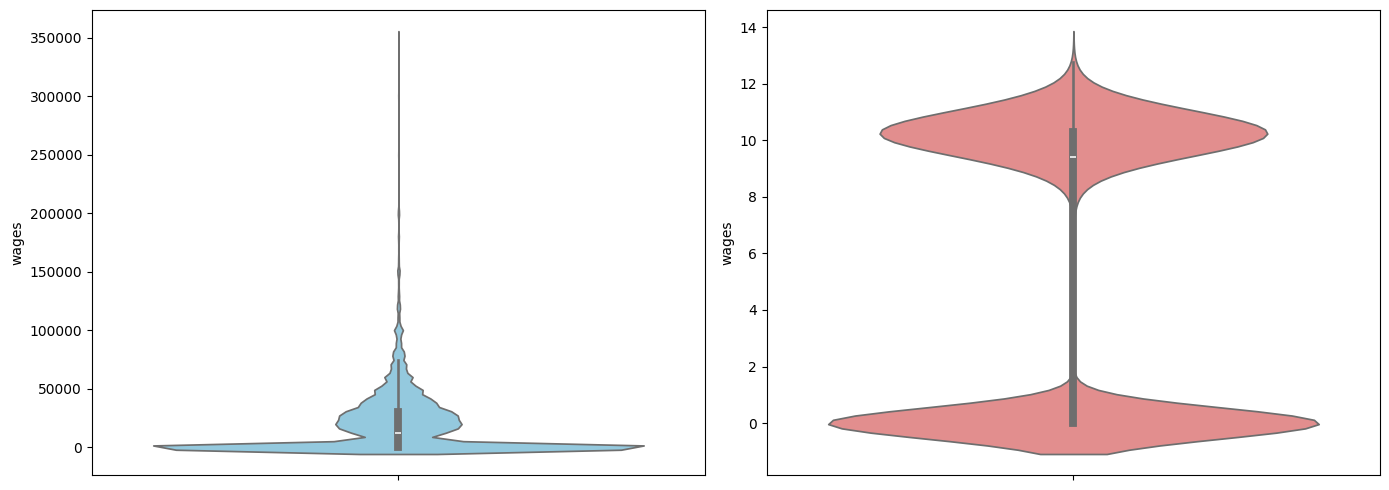

In [274]:
wages_original = panel['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

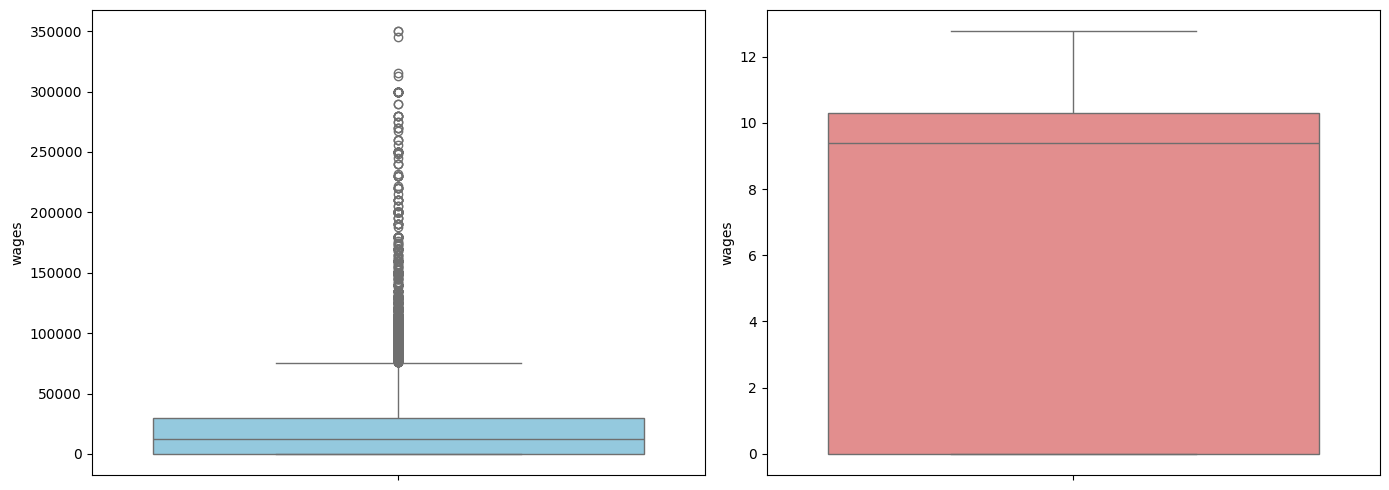

In [275]:
wages_original = panel['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [276]:
common_people = panel.filter(pl.col('year') == 2021)[['idind']].join(panel.filter(pl.col('year') == 2020)[['idind']], how='inner', on='idind').sort('idind').unique()
common_people

idind
f64
29.0
36.0
180.0
188.0
305.0
…
60464.0
60465.0
60467.0


In [277]:
panel_common_2019_2020 = panel.filter(
    pl.col('idind').is_in(common_people['idind'].implode())
).sort('idind')
panel_common_2019_2020

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,is_employed,has_disablity,wages
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,str,str,str,f64,str,str,str,i32,i32,f64
29.0,2017.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",0,0,0.0
29.0,2020.0,"""No""","""No""",0.0,0.0,43000.0,0.0,43000.0,0.0,"""Yes""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,43000.0
29.0,2021.0,"""Yes""","""Yes""",11300.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,0.0
36.0,2019.0,"""Yes""","""Yes""",14700.0,0.0,14700.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""Yes""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",65.0,"""8 grades of school""","""In a registered marriage""","""FEMALE""",0,0,0.0
36.0,2020.0,"""Yes""","""Yes""",16300.0,0.0,16300.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""Yes""","""No""","""No""","""No""","""No""",null,"""September""",29.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",66.0,"""8 grades of school""","""In a registered marriage""","""FEMALE""",0,0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60467.0,2022.0,"""No""","""No""",0.0,0.0,38000.0,0.0,37000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""December""",17.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",47.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""",1,0,37000.0
60473.0,2020.0,"""No""","""No""",0.0,0.0,40000.0,0.0,40000.0,0.0,"""Yes""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""",1,0,40000.0
60473.0,2021.0,"""No""","""No""",0.0,0.0,55000.0,0.0,35000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…","""FEMALE""",1,0,35000.0


In [278]:
education_levels = pl.read_excel('../data/all_education_levels.xlsx', sheet_name='selected_levels')
marital_status = pl.read_excel('../data/all_marst_levels.xlsx', sheet_name='selected_levels')
period_relevance = pl.read_excel('../data/period_relevance.xlsx').with_columns(
    pl.col('year').cast(pl.Float64)
)
is_town = pl.read_excel('../data/is_town.xlsx')

In [279]:
panel_common_2019_2020 = (
    panel_common_2019_2020
        .join(education_levels, on='educ', how='left', validate='m:1')
        .with_columns(pl.col('educ_level').fill_null('school_or_less'))
        .join(marital_status, on='marst', how='left', validate='m:1')
        .join(period_relevance, on='year', how='left', validate='m:1')
        .join(is_town, right_on='status', left_on='habitat', how='left', validate='m:1')
        .with_columns(pl.col('is_married').fill_null(0))
        .with_columns(
            is_female = pl.when(pl.col('gender') == 'FEMALE').then(1).otherwise(0),
        ).with_columns(
            pl.when(pl.col('hearing_disability') == 'Yes').then(1).otherwise(0).alias('hearing_disability'),
            pl.when(pl.col('eye_disability') == 'Yes').then(1).otherwise(0).alias('eye_disability'),
            pl.when(pl.col('spinal_disability') == 'Yes').then(1).otherwise(0).alias('spinal_disability'),
            pl.when(pl.col('neuro_disability') == 'Yes').then(1).otherwise(0).alias('neuro_disability'),
        )
        #.filter(pl.col('idind').is_in(common_people))
)#.drop(cols_disease) 
panel_common_2019_2020

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,is_employed,has_disablity,wages,educ_level,is_married,period_relevance,is_town,is_female
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,i32,i32,f64,str,i64,i64,i64,i32
29.0,2017.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",0,0,0.0,"""higher""",0,-2,1,1
29.0,2020.0,"""No""","""No""",0.0,0.0,43000.0,0.0,43000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,43000.0,"""higher""",0,1,1,1
29.0,2021.0,"""Yes""","""Yes""",11300.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,0.0,"""higher""",0,2,1,1
36.0,2019.0,"""Yes""","""Yes""",14700.0,0.0,14700.0,0.0,0.0,0.0,"""No""","""You are not working""",0,1,0,0,"""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",65.0,"""8 grades of school""","""In a registered marriage""","""FEMALE""",0,0,0.0,"""school_or_less""",1,0,1,1
36.0,2020.0,"""Yes""","""Yes""",16300.0,0.0,16300.0,0.0,0.0,0.0,"""No""","""You are not working""",0,1,0,0,"""No""","""No""",null,"""September""",29.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",66.0,"""8 grades of school""","""In a registered marriage""","""FEMALE""",0,0,0.0,"""school_or_less""",1,1,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60467.0,2022.0,"""No""","""No""",0.0,0.0,38000.0,0.0,37000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",17.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",47.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""",1,0,37000.0,"""university""",0,3,1,1
60473.0,2020.0,"""No""","""No""",0.0,0.0,40000.0,0.0,40000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""",1,0,40000.0,"""common""",1,1,1,1
60473.0,2021.0,"""No""","""No""",0.0,0.0,55000.0,0.0,35000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…","""FEMALE""",1,0,35000.0,"""common""",1,2,1,1


In [281]:
(
    panel_common_2019_2020[['year', 'has_disablity']]
    .group_by('year').agg(pl.col('has_disablity').sum())
    .sort('year')
)

year,has_disablity
f64,i32
2015.0,86
2016.0,109
2017.0,131
2018.0,156
2019.0,183
2020.0,356
2021.0,366
2022.0,208
2023.0,186


In [282]:
working_statuses = (
    panel_common_2019_2020[['idind', 'year', 'is_employed']]
    .pivot(index='idind', on='year', values='is_employed')
                   )
working_statuses

idind,2017.0,2020.0,2021.0,2019.0,2022.0,2015.0,2023.0,2018.0,2024.0,2016.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
29.0,0,1,1,null,null,null,null,null,null,null
36.0,null,0,0,0,1,null,null,null,null,null
180.0,null,1,1,null,null,1,1,null,null,null
188.0,0,0,0,null,null,null,null,null,null,null
305.0,0,0,0,null,null,0,0,0,null,null
…,…,…,…,…,…,…,…,…,…,…
60464.0,null,1,1,null,null,null,1,null,null,null
60465.0,null,1,1,null,null,null,1,null,null,null
60467.0,null,1,1,null,1,null,null,null,null,null


In [283]:
working_statuses_1 = working_statuses.filter(
    (pl.col('2019.0') == 1) | (pl.col('2020.0') == 1)
)
working_statuses_1

idind,2017.0,2020.0,2021.0,2019.0,2022.0,2015.0,2023.0,2018.0,2024.0,2016.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
29.0,0,1,1,null,null,null,null,null,null,null
180.0,null,1,1,null,null,1,1,null,null,null
434.0,1,1,1,1,null,null,null,null,null,null
454.0,null,1,0,null,0,null,0,null,0,null
541.0,null,1,1,null,1,null,1,null,1,null
…,…,…,…,…,…,…,…,…,…,…
60464.0,null,1,1,null,null,null,1,null,null,null
60465.0,null,1,1,null,null,null,1,null,null,null
60467.0,null,1,1,null,1,null,null,null,null,null


In [284]:
disability_statuses = (
    panel_common_2019_2020[['idind', 'year', 'has_disablity']]
    .pivot(index='idind', on='year', values='has_disablity')
                   )
disability_statuses

idind,2017.0,2020.0,2021.0,2019.0,2022.0,2015.0,2023.0,2018.0,2024.0,2016.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
29.0,0,0,0,null,null,null,null,null,null,null
36.0,null,0,0,0,0,null,null,null,null,null
180.0,null,0,0,null,null,0,0,null,null,null
188.0,1,1,1,null,null,null,null,null,null,null
305.0,0,1,1,null,null,0,0,0,null,null
…,…,…,…,…,…,…,…,…,…,…
60464.0,null,0,0,null,null,null,0,null,null,null
60465.0,null,0,0,null,null,null,0,null,null,null
60467.0,null,0,0,null,0,null,null,null,null,null


In [285]:
disability_statuses_common = disability_statuses.filter(
    (pl.col('2019.0') == 1) | (pl.col('2020.0') == 1)
)
disability_statuses_common

idind,2017.0,2020.0,2021.0,2019.0,2022.0,2015.0,2023.0,2018.0,2024.0,2016.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
188.0,1,1,1,null,null,null,null,null,null,null
305.0,0,1,1,null,null,0,0,0,null,null
528.0,null,1,1,1,1,null,1,1,null,null
1177.0,null,1,1,null,null,null,null,1,null,null
1482.0,null,1,1,1,0,null,1,null,null,null
…,…,…,…,…,…,…,…,…,…,…
60220.0,null,1,1,null,null,null,null,null,1,null
60294.0,null,1,1,null,null,null,null,null,null,null
60396.0,null,1,1,null,1,null,1,null,null,null


In [286]:
panel_common_2019_2020 = panel_common_2019_2020.with_columns(
    pl.when(pl.col('idind').is_in(disability_statuses_common['idind'].implode()))
    .then(1).otherwise(0).alias('has_disability_common')
)
panel_common_2019_2020

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,is_employed,has_disablity,wages,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,i32,i32,f64,str,i64,i64,i64,i32,i32
29.0,2017.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",0,0,0.0,"""higher""",0,-2,1,1,0
29.0,2020.0,"""No""","""No""",0.0,0.0,43000.0,0.0,43000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,43000.0,"""higher""",0,1,1,1,0
29.0,2021.0,"""Yes""","""Yes""",11300.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,0.0,"""higher""",0,2,1,1,0
36.0,2019.0,"""Yes""","""Yes""",14700.0,0.0,14700.0,0.0,0.0,0.0,"""No""","""You are not working""",0,1,0,0,"""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",65.0,"""8 grades of school""","""In a registered marriage""","""FEMALE""",0,0,0.0,"""school_or_less""",1,0,1,1,0
36.0,2020.0,"""Yes""","""Yes""",16300.0,0.0,16300.0,0.0,0.0,0.0,"""No""","""You are not working""",0,1,0,0,"""No""","""No""",null,"""September""",29.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",66.0,"""8 grades of school""","""In a registered marriage""","""FEMALE""",0,0,0.0,"""school_or_less""",1,1,1,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60467.0,2022.0,"""No""","""No""",0.0,0.0,38000.0,0.0,37000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",17.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",47.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""",1,0,37000.0,"""university""",0,3,1,1,0
60473.0,2020.0,"""No""","""No""",0.0,0.0,40000.0,0.0,40000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""",1,0,40000.0,"""common""",1,1,1,1,0
60473.0,2021.0,"""No""","""No""",0.0,0.0,55000.0,0.0,35000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…","""FEMALE""",1,0,35000.0,"""common""",1,2,1,1,0


In [287]:
(
    panel_common_2019_2020
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('wages').mean())
).plot.line(x='year', y='wages', color='has_disablity')

alt.Chart(...)

In [288]:
(
    panel_common_2019_2020
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disability_common']).agg(pl.col('wages').mean())
).plot.line(x='year', y='wages', color='has_disability_common')

alt.Chart(...)

In [289]:
working_data = (
    panel_common_2019_2020
    .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
    .sort(['idind', 'year'])
)
working_data

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,is_employed,has_disablity,wages,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,i32,i32,f64,str,i64,i64,i64,i32,i32
29.0,2017.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",0,0,0.0,"""higher""",0,-2,1,1,0
29.0,2020.0,"""No""","""No""",0.0,0.0,43000.0,0.0,43000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,43000.0,"""higher""",0,1,1,1,0
29.0,2021.0,"""Yes""","""Yes""",11300.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""",1,0,0.0,"""higher""",0,2,1,1,0
180.0,2015.0,"""No""","""No""",0.0,3000.0,21000.0,0.0,10000.0,8000.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",6.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",38.5,"""3 and more years in Institute,…","""Divorsed and not remarried""","""FEMALE""",1,0,18000.0,"""university""",0,-4,0,1,0
180.0,2020.0,"""No""","""No""",0.0,0.0,32000.0,0.0,25000.0,7000.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",25.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",43.5,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""",1,0,32000.0,"""university""",1,1,0,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60467.0,2022.0,"""No""","""No""",0.0,0.0,38000.0,0.0,37000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",17.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",47.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""",1,0,37000.0,"""university""",0,3,1,1,0
60473.0,2020.0,"""No""","""No""",0.0,0.0,40000.0,0.0,40000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""",1,0,40000.0,"""common""",1,1,1,1,0
60473.0,2021.0,"""No""","""No""",0.0,0.0,55000.0,0.0,35000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…","""FEMALE""",1,0,35000.0,"""common""",1,2,1,1,0


In [347]:
# working_data.write_parquet('../data/wages_working_data.parquet')

In [290]:
working_data.filter(pl.col('has_disablity') == 1).plot.boxplot(y='wages').properties(width=100, height=350)

alt.Chart(...)

In [291]:
alt.data_transformers.enable("vegafusion")
working_data.filter(pl.col('has_disablity') == 0).plot.boxplot(y='wages').properties(width=100, height=350)

alt.Chart(...)

In [342]:
panel2019_2020 = (
    working_data
        # .filter(pl.col())
        # .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(
            pl.col('year').is_in([2020, 2021])
        )
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        
).to_pandas().set_index(['idind', 'year'])
panel2019_2020

recieves_pension recieves_pension_30days  amount_pension  \
idind   year                                                                  
29.0    2020-01-01               No                      No             0.0   
        2021-01-01              Yes                     Yes         11300.0   
180.0   2020-01-01               No                      No             0.0   
        2021-01-01               No                      No             0.0   
434.0   2020-01-01               No                      No             0.0   
...                             ...                     ...             ...   
60467.0 2021-01-01               No                      No             0.0   
60473.0 2020-01-01               No                      No             0.0   
        2021-01-01               No                      No             0.0   
60474.0 2020-01-01              Yes                     Yes         15600.0   
        2021-01-01              Yes                     Yes         16200.0   

                    iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                                   
29.0    2020-01-01         0.0       43000.0                    0.0  43000.0   
        2021-01-01         0.0           0.0                    0.0      0.0   
180.0   2020-01-01         0.0       32000.0                    0.0  25000.0   
        2021-01-01         0.0       24000.0                    0.0  24000.0   
434.0   2020-01-01         0.0       20000.0                    0.0  10000.0   
...                        ...           ...                    ...      ...   
60467.0 2021-01-01         0.0       31000.0                    0.0      0.0   
60473.0 2020-01-01         0.0       40000.0                    0.0  40000.0   
        2021-01-01         0.0       55000.0                    0.0  35000.0   
60474.0 2020-01-01         0.0       15600.0                    0.0      0.0   
        2021-01-01         0.0       31200.0                    0.0  14000.0   

                    wage_j2 income_decrease_bc_covid  \
idind   year                                           
29.0    2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
180.0   2020-01-01   7000.0                       No   
        2021-01-01      0.0                       No   
434.0   2020-01-01      0.0                       No   
...                     ...                      ...   
60467.0 2021-01-01      0.0                       No   
60473.0 2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
60474.0 2020-01-01      0.0                       No   
        2021-01-01      0.0                       No   

                                                          work_status  ...  \
idind   year                                                           ...   
29.0    2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   
180.0   2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   
434.0   2020-01-01                          You are currently working  ...   
...                                                               ...  ...   
60467.0 2021-01-01  You are on paid leave: maternity leave or taki...  ...   
60473.0 2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   
60474.0 2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   

                    gender  is_employed  has_disablity    wages  educ_level  \
idind   year                                                                  
29.0    2020-01-01  FEMALE            1         

In [343]:
model1 = PanelOLS.from_formula('np.log(wages + 1) ~ has_disablity + EntityEffects', data=panel2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      np.log(wages + 1)   R-squared:                        0.0024
Estimator:                   PanelOLS   R-squared (Between):             -0.0147
No. Observations:                4644   R-squared (Within):               0.0024
Date:                Sun, Apr 26 2026   R-squared (Overall):             -0.0141
Time:                        12:52:42   Log-likelihood                   -9448.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5.5121
Entities:                        2322   P-value                           0.0190
Avg Obs:                       2.0000   Distribution:                  F(1,2321)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.5121
                            

In [346]:
model3 = PanelOLS.from_formula('wages ~ has_disablity + EntityEffects', data=panel2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):             -0.0128
No. Observations:                4644   R-squared (Within):               0.0016
Date:                Sun, Apr 26 2026   R-squared (Overall):             -0.0119
Time:                        12:53:11   Log-likelihood                -4.909e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.7555
Entities:                        2322   P-value                           0.0528
Avg Obs:                       2.0000   Distribution:                  F(1,2321)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.6344
                            

In [296]:
-1.493e+04

-14930.0

In [297]:
panel2019_2020 = (
    working_data
        # .filter(pl.col())
        #.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        #.with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .with_columns(
            period = pl.when(pl.col('year') == 2020).then(1).otherwise(0)
        )
).to_pandas()
panel2019_2020

,idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,...,is_employed,has_disablity,wages,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common,period
0,29.0,2017.0,No,No,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,higher,0,-2,1,1,0,0
1,29.0,2020.0,No,No,0.0,0.0,43000.0,0.0,43000.0,0.0,...,1,0,43000.0,higher,0,1,1,1,0,1
2,29.0,2021.0,Yes,Yes,11300.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0.0,higher,0,2,1,1,0,0
3,180.0,2015.0,No,No,0.0,3000.0,21000.0,0.0,10000.0,8000.0,...,1,0,18000.0,university,0,-4,0,1,0,0
4,180.0,2020.0,No,No,0.0,0.0,32000.0,0.0,25000.0,7000.0,...,1,0,32000.0,university,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13992,60467.0,2022.0,No,No,0.0,0.0,38000.0,0.0,37000.0,0.0,...,1,0,37000.0,university,0,3,1,1,0,0
13993,60473.0,2020.0,No,No,0.0,0.0,40000.0,0.0,40000.0,0.0,...,1,0,40000.0,common,1,1,1,1,0,1
13994,60473.0,2021.0,No,No,0.0,0.0,55000.0,0.0,35000.0,0.0,...,1,0,35000.0,common,1,2,1,1,0,0
13995,60474.0,2020.0,Yes,Yes,15600.0,0.0,15600.0,0.0,0.0,0.0,...,1,0,0.0,common,1,1,1,0,0,1


In [298]:
ols1 = smf.ols('wages ~ has_disability + period + I(has_disability * period)', panel2019_2020).fit()
print(ols1.summary2())

                                                       Results: Ordinary least squares
Model:                                       OLS                                      Adj. R-squared:                             0.001      
Dependent Variable:                          wages                                    AIC:                                        326180.2405
Date:                                        2026-04-26 10:25                         BIC:                                        326217.9735
No. Observations:                            13997                                    Log-Likelihood:                             -1.6309e+05
Df Model:                                    4                                        F-statistic:                                4.736      
Df Residuals:                                13992                                    Prob (F-statistic):                         0.000810   
R-squared:                                   0.001           

# event study model

In [325]:
panel_2014_2024 = (
    working_data
        #.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        #.filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(
            (pl.col('period_relevance') > -5) & (pl.col('period_relevance') < 5)
        )
        # .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas()
panel_2014_2024_dta = panel_2014_2024.set_index(['idind', 'year'])
panel_2014_2024_dta

recieves_pension recieves_pension_30days  amount_pension  \
idind   year                                                                  
29.0    2017-01-01               No                      No             0.0   
        2020-01-01               No                      No             0.0   
        2021-01-01              Yes                     Yes         11300.0   
180.0   2015-01-01               No                      No             0.0   
        2020-01-01               No                      No             0.0   
...                             ...                     ...             ...   
60467.0 2022-01-01               No                      No             0.0   
60473.0 2020-01-01               No                      No             0.0   
        2021-01-01               No                      No             0.0   
60474.0 2020-01-01              Yes                     Yes         15600.0   
        2021-01-01              Yes                     Yes         16200.0   

                    iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                                   
29.0    2017-01-01         0.0           0.0                    0.0      0.0   
        2020-01-01         0.0       43000.0                    0.0  43000.0   
        2021-01-01         0.0           0.0                    0.0      0.0   
180.0   2015-01-01      3000.0       21000.0                    0.0  10000.0   
        2020-01-01         0.0       32000.0                    0.0  25000.0   
...                        ...           ...                    ...      ...   
60467.0 2022-01-01         0.0       38000.0                    0.0  37000.0   
60473.0 2020-01-01         0.0       40000.0                    0.0  40000.0   
        2021-01-01         0.0       55000.0                    0.0  35000.0   
60474.0 2020-01-01         0.0       15600.0                    0.0      0.0   
        2021-01-01         0.0       31200.0                    0.0  14000.0   

                    wage_j2 income_decrease_bc_covid  \
idind   year                                           
29.0    2017-01-01      0.0                       No   
        2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
180.0   2015-01-01   8000.0                       No   
        2020-01-01   7000.0                       No   
...                     ...                      ...   
60467.0 2022-01-01      0.0                       No   
60473.0 2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
60474.0 2020-01-01      0.0                       No   
        2021-01-01      0.0                       No   

                                  work_status  ...  gender  is_employed  \
idind   year                                   ...                        
29.0    2017-01-01        You are not working  ...  FEMALE            0   
        2020-01-01  You are currently working  ...  FEMALE            1   
        2021-01-01  You are currently working  ...  FEMALE            1   
180.0   2015-01-01  You are currently working  ...  FEMALE            1   
        2020-01-01  You are currently working  ...  FEMALE            1   
...                                       ...  ...     ...          ...   
60467.0 2022-01-01  You are currently working  ...  FEMALE            1   
60473.0 2020-01-01  You are currently working  ...  FEMALE            1   
        2021-01-01  You are currently working  ...  FEMALE            1   
60474.0 2020-01-01  You are currently working  ...    MALE            1   
        2021-01-01  You are currently working  ...    MALE            1   

                    has_disablity    wages  educ_level is_married  \
idind   year                                                        
29.0    2017-01-01              0      0.0      higher          0   
        2020-01-01              0  430

In [340]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['has_disability_common'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['wages']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=False, check_rank=False).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                       -2.8467
Estimator:                   PanelOLS   R-squared (Between):             -3.2687
No. Observations:               12790   R-squared (Within):              -0.3923
Date:                Sun, Apr 26 2026   R-squared (Overall):             -2.2506
Time:                        12:52:03   Log-likelihood                -1.504e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                     -1105.9
Entities:                        2322   P-value                           1.0000
Avg Obs:                       5.5082   Distribution:                 F(7,10461)
Min Obs:                       2.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             8.1253
                            

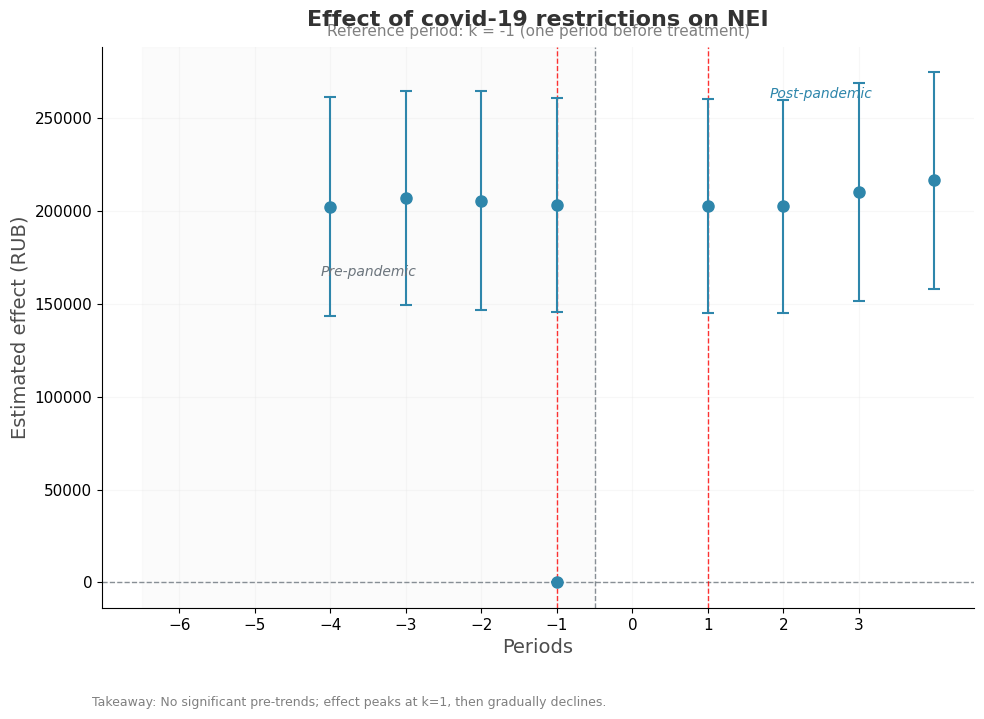

In [339]:
plot_event_margins(event_study_model_reduced)